# 03 — Signal sensitivity per plane

For each plane with a measurable closure anchor (even half): signal efficiency into
A, sideband leakage, the bias that leakage induces in the background prediction as
a function of signal strength, and an Asimov-Z ranking. Two definitions used
throughout: **leakage** S(region)/S(A) is the fraction of signal falling into each
sideband relative to the signal region — ABCD subtracts the sidebands' content
from the SR estimate, so signal leaking there makes the method subtract signal
from itself (sidebands must be signal-depleted); **Asimov Z** is the median
discovery significance expected if the signal were present at the stated cross
section, computed from expected yields alone (the asymptotic formula) — used here
only to RANK planes, not as a sensitivity claim. Signal normalization uses the
census gen-filter denominators (absolute efficiency is honest).

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

sys.path.insert(0, os.getcwd())
import abcd_tools as at
import study_setup as ss

import plot_helpers as ph

hep.style.use("CMS")
plt.rcParams["figure.figsize"] = (9, 7)
# even-parity half of the sample = half the effective luminosity
LUMI_LABEL = ph.LUMI_EVEN
cms_label = ph.cms_label

# pre-skim / pre-filter sums of gen weights (see README "Normalization")
SUMW_PRE = {}
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_SIGNAL_2MU2E))
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_SIGNAL_4MU))
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_BKG_UNSKIMMED))
SUMW_PRE.update(ss.SUMW_PRE_OVERRIDES)   # DY rogue-file repair (see study_setup)

# normalization tripwire: a factor outside [1e-5, 1] means a broken denominator
for _s in ss.ANALYSIS_BACKGROUNDS:
    _f = ss.fetch(_s)["metadata"]["scaled_sum_weights"] / SUMW_PRE[_s] / ss.FW.get(_s, 1.0)
    assert 1e-5 < _f <= 1.0, f"normalization factor out of range for {_s}: {_f:.3g}"

# Background sums built ONE SAMPLE AT A TIME (holding all 44 samples in memory OOMs
# the interactive node); signals are loaded lazily where needed, one at a time.
# TTJets kept at the campaign 471.7 pb; the NNLO alternative is an explicit rescale.
total_bkg, by_process = ss.accumulate_normalized(list(ss.ANALYSIS_BACKGROUNDS), SUMW_PRE)
def load_sig(s):
    return ss.load_normalized(s, SUMW_PRE)[0]
print(f"accumulated {len(ss.ANALYSIS_BACKGROUNDS)} background samples "
      f"(DYJetsToMuMu_M50 excluded); scan hists: {len(total_bkg)}")

accumulated 17 background samples (DYJetsToMuMu_M50 excluded); scan hists: 8


## Which mass points carry the search

Cross sections from the darkonium engine at the dijet-constrained mediator benchmark
(m_A = 750 GeV; notebook 01 shows the full σ(m_B) curve). The Z ranking below uses
the 1 fb reference convention; this table is the reality check on which points that
convention should be read for.

In [2]:
sys.path.insert(0, os.path.join(os.getcwd(), "..", "pseudoscalar_xsec"))
import pseudoscalar_xsec as px
from mstwpdf import MSTWPDF
pdf = MSTWPDF(os.path.join(os.getcwd(), "..", "pseudoscalar_xsec", "mstw2008nnlo.00.dat"))
masses = [100., 500., 1000.]
_, _, tots = px.scan_mB(pdf, np.array(masses), mA=750, tanb=1, alphaD=0.2, yq=1, ychi=1)
print(f"{'m_B [GeV]':>10s} {'sigma [fb]':>12s} {'produced in 59.8/fb':>20s}")
for m, t in zip(masses, tots):
    print(f"{m:10.0f} {t:12.4g} {t*59.83:20.1f}")
print()
print("m_B <= 200 GeV is produced at < 0.05 fb (< 3 events in all of 2018) at this")
print("benchmark: the 100 GeV points are ILLUSTRATIVE, not search targets.")

 m_B [GeV]   sigma [fb]  produced in 59.8/fb
       100     0.009751                  0.6
       500        1.264                 75.6
      1000       0.3416                 20.4

m_B <= 200 GeV is produced at < 0.05 fb (< 3 events in all of 2018) at this
benchmark: the 100 GeV points are ILLUSTRATIVE, not search targets.


In [3]:
# Sensitivity per plane x prescription x signal point. The background prediction at
# the SR working point uses B*C/D from the (sparse) tight regions; its uncertainty
# folds the MC-stat error with the non-closure systematic from the notebook-02
# projection: syst = |R_proj - 1| (+) R_proj_err. Planes without a valid projection
# are skipped (nothing defensible to quote).
gates = json.load(open(os.path.join(ss.WORKDIR, "gates_even.json")))
results = {}
for ch, signals in [("2mu2e", ss.SIGNALS_2MU2E), ("4mu", ss.SIGNALS_4MU)]:
    for pname, spec in ss.PLANES[ch].items():
        for presc in ["i", "iii"]:
            g3 = gates["gate3"].get(f"{ch}/{pname}/{presc}") or {}
            if "syst" not in g3:
                continue
            syst = g3["syst"]
            lo = dict(xlo=0.0, ylo=0.0) if presc == "iii" else {}
            bvals, bvar, xe, ye = ss.plane_arrays(total_bkg, ch, pname, parity=0)
            breg = at.region_sums(bvals, bvar, xe, ye, spec["xspec"], spec["yspec"], **lo)
            bpred, bpred_var = at.abcd_prediction(breg)
            if not np.isfinite(bpred):
                continue
            sigma_b = np.sqrt(max(bpred_var, 0) + (syst * bpred) ** 2)
            for s in signals:
                svals, svar, sxe, sye = ss.plane_arrays(load_sig(s), ch, pname, parity=0)
                sreg = at.region_sums(svals, svar, sxe, sye, spec["xspec"], spec["yspec"], **lo)
                results[f"{ch}/{pname}/{presc}/{s}"] = {
                    "S_A": sreg["A"][0], "B_pred": bpred, "sigma_B": sigma_b,
                    "Z": at.asimov_z(sreg["A"][0], max(bpred, 1e-4), sigma_b),
                    "leakage": at.leakage_ratios(sreg)}
json.dump(results, open(os.path.join(ss.WORKDIR, "sensitivity_even.json"), "w"),
          indent=1, default=float)
print(f"{len(results)} plane x prescription x signal evaluations")
print("NOTE: Z values use tight-region B*C/D predictions from the n_eff~1 regime -")
print("indicative ranking only, NOT calibrated significances (see notebook 02).")

# prediction bias vs signal strength for the leading plane (its C sideband hosts the
# proposed low-mass SR, so signal leakage there matters most)
spec = ss.PLANES["2mu2e"]["P4_muiso_mjj"]
bvals, bvar, xe, ye = ss.plane_arrays(total_bkg, "2mu2e", "P4_muiso_mjj", parity=0)
breg = at.region_sums(bvals, bvar, xe, ye, spec["xspec"], spec["yspec"])
print("P4 leakage per signal point (S_region/S_A) and prediction bias vs mu:")
for s in ss.SIGNALS_2MU2E:
    sv, sw, sxe, sye = ss.plane_arrays(load_sig(s), "2mu2e", "P4_muiso_mjj", parity=0)
    sreg = at.region_sums(sv, sw, sxe, sye, spec["xspec"], spec["yspec"])
    lr = at.leakage_ratios(sreg)
    bias = at.prediction_bias_vs_mu(breg, sreg, [1.0])[0][1]
    fmt = {k: (f"{v:.2e}" if np.isfinite(v) else "-") for k, v in lr.items()}
    print(f"  {s:34s} B/A={fmt['B']} C/A={fmt['C']} D/A={fmt['D']} "
          f"bias(mu=1)={bias if np.isfinite(bias) else float('nan'):.3f}")

221 plane x prescription x signal evaluations
NOTE: Z values use tight-region B*C/D predictions from the n_eff~1 regime -
indicative ranking only, NOT calibrated significances (see notebook 02).
P4 leakage per signal point (S_region/S_A) and prediction bias vs mu:


  2Mu2E_100GeV_1p2GeV_0p096mm        B/A=- C/A=- D/A=- bias(mu=1)=0.000


  2Mu2E_100GeV_1p2GeV_9p6mm          B/A=3.57e-02 C/A=2.34e+01 D/A=1.36e+00 bias(mu=1)=0.000


  2Mu2E_100GeV_1p2GeV_96p0mm         B/A=0.00e+00 C/A=2.60e+01 D/A=4.00e+00 bias(mu=1)=0.000


  2Mu2E_500GeV_1p2GeV_0p019mm        B/A=7.58e-03 C/A=0.00e+00 D/A=0.00e+00 bias(mu=1)=0.000


...

  2Mu2E_1000GeV_1p2GeV_9p6mm         B/A=1.61e-02 C/A=0.00e+00 D/A=0.00e+00 bias(mu=1)=0.000


  2Mu2E_500GeV_0p25GeV_0p4mm         B/A=5.44e-03 C/A=0.00e+00 D/A=0.00e+00 bias(mu=1)=0.000


  2Mu2E_500GeV_0p25GeV_4p0mm         B/A=1.40e-02 C/A=3.26e-04 D/A=0.00e+00 bias(mu=1)=0.000


  2Mu2E_500GeV_5p0GeV_8p0mm          B/A=6.48e-03 C/A=8.64e-05 D/A=0.00e+00 bias(mu=1)=0.000


  2Mu2E_500GeV_5p0GeV_80p0mm         B/A=2.11e-02 C/A=0.00e+00 D/A=0.00e+00 bias(mu=1)=0.000


plane                     median Z   max Z  worst leakage
4mu/Q5_dphi_mjj/i            1.445   3.746         38.274
4mu/Q5_dphi_mjj/iii          1.445   3.746         38.274
4mu/Q6_iso0_mjj/iii          1.269   3.641         38.102
4mu/Q2_iso0_dphi/iii         1.269   3.641          0.060
4mu/Q6_iso0_mjj/i            0.860   2.356         38.274
4mu/Q1_iso_iso/i             0.514   1.648          0.125
4mu/Q1_iso_iso/iii           0.370   1.546          0.200
2mu2e/P4_muiso_mjj/i         0.215   1.006         26.000
2mu2e/P9_egmiso_mjj/iii      0.169   0.794         27.821
2mu2e/P9_egmiso_mjj/i        0.169   0.791         27.821
2mu2e/P4_muiso_mjj/iii       0.166   0.977         30.263
2mu2e/P1_iso_iso/i           0.046   0.277          0.857
2mu2e/P1_iso_iso/iii         0.034   0.266          1.158
2mu2e/P8_dphi_mjj/i          0.010   0.064         26.000
2mu2e/P8_dphi_mjj/iii        0.010   0.064         26.000
2mu2e/P2_muiso_dphi/i        0.002   0.011          0.036
2mu2e/P2_muiso

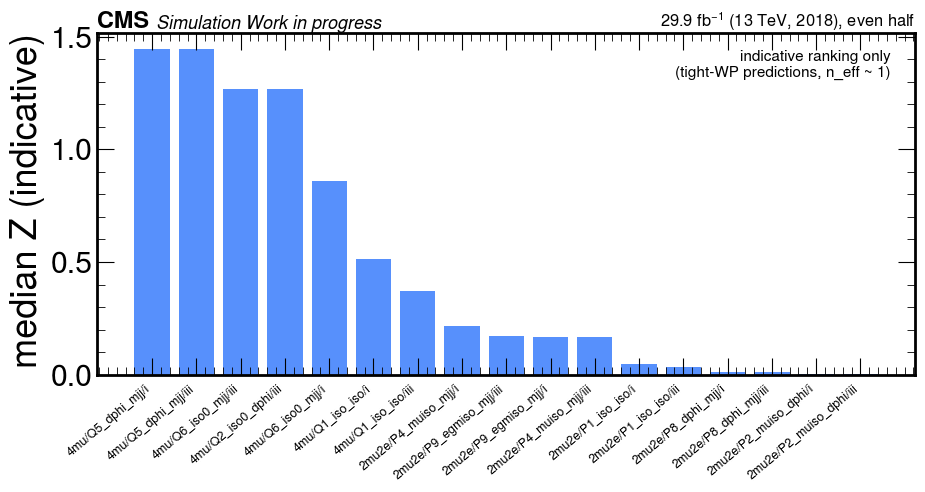

In [4]:
# ranking summary: median Z across signal points per plane, worst-case leakage
import collections
agg = collections.defaultdict(list)
for key, r in results.items():
    ch, pname, presc, s = key.split("/", 3)
    lk = [v for v in r["leakage"].values() if np.isfinite(v)]
    agg[f"{ch}/{pname}/{presc}"].append((r["Z"], np.nanmax(lk) if lk else np.nan))
print(f"{'plane':24s} {'median Z':>9s} {'max Z':>7s} {'worst leakage':>14s}")
ranked = sorted(agg.items(), key=lambda kv: -np.median([x[0] for x in kv[1]]))
for k, v in ranked:
    zs = [x[0] for x in v]; ls = [x[1] for x in v]
    wl = np.nanmax(ls) if np.any(np.isfinite(ls)) else np.nan
    wls = f"{wl:14.3f}" if np.isfinite(wl) else f"{'-':>14s}"
    print(f"{k:24s} {np.median(zs):9.3f} {max(zs):7.3f} {wls}")
print("(Q2 and Q6 Z columns coincide where B_pred hits the 1e-4 floor and both")
print(" A regions are the same event set - not independent corroboration)")
fig, axx = plt.subplots(figsize=(10, 5.5))
labs = [k for k, _ in ranked]
meds = [np.median([x[0] for x in v]) for _, v in ranked]
axx.bar(labs, meds, color="C0")
axx.set_ylabel("median Z (indicative)")
axx.set_xticks(np.arange(len(labs)), labs, rotation=40, ha="right", fontsize=9)
axx.text(0.97, 0.95, "indicative ranking only\n(tight-WP predictions, n_eff ~ 1)",
         transform=axx.transAxes, va="top", ha="right", fontsize=11)
cms_label(axx); plt.tight_layout(); plt.show()

## Sensitivity and purity, drawn

Three views per key plane. (1) Signal yield into the A region vs lifetime — the
efficiency story per mass. (2) Sideband leakage per point — ABCD sidebands must be
signal-depleted; this is where the egm-iso axis (P9, and P1's egm sideband) fails
for displaced signals, while P4's mu-iso and low-mJJ sidebands stay clean for every
theory-relevant mass (the large m_B = 100 bars are the illustrative points sitting
below the mJJ boundary). (3) The bias a signal of strength μ would induce in P4's
background prediction through its sidebands.

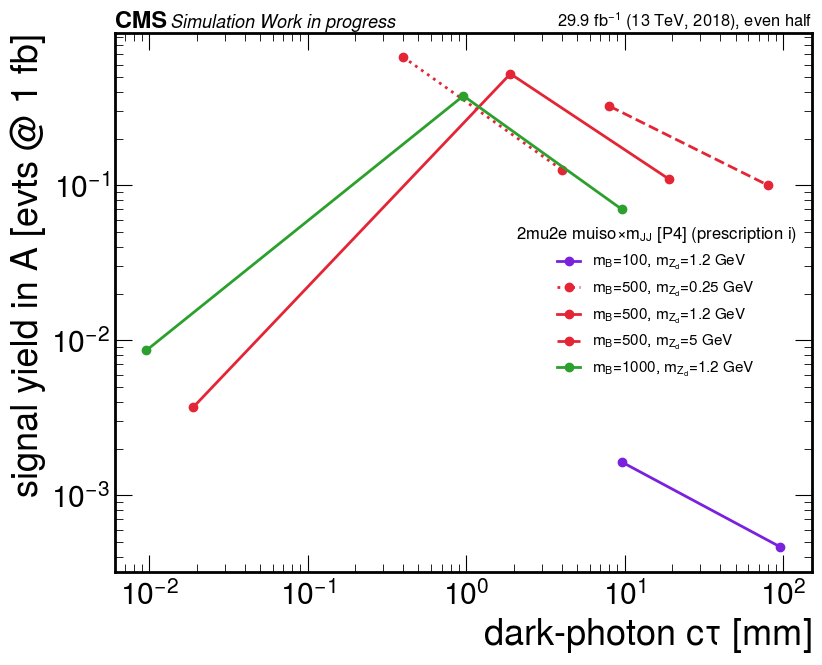

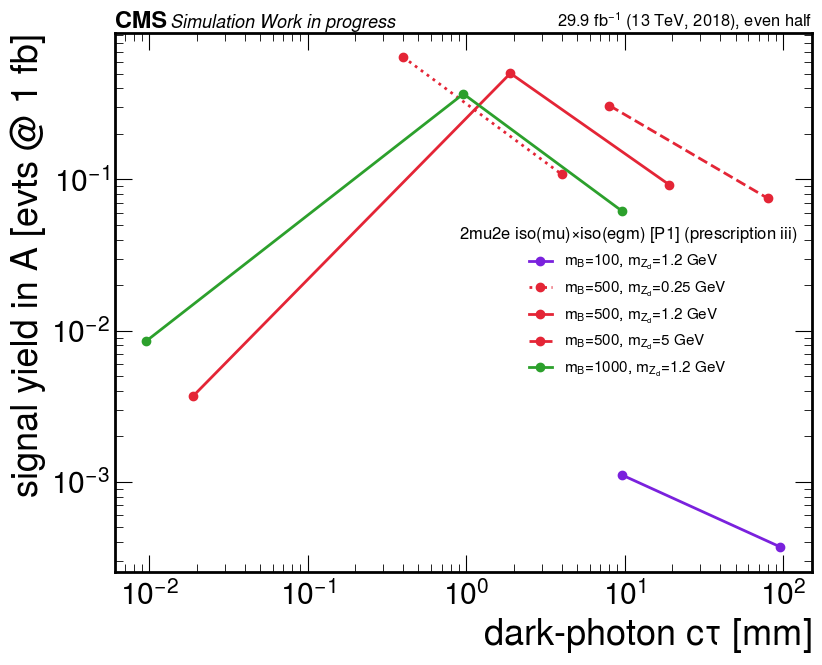

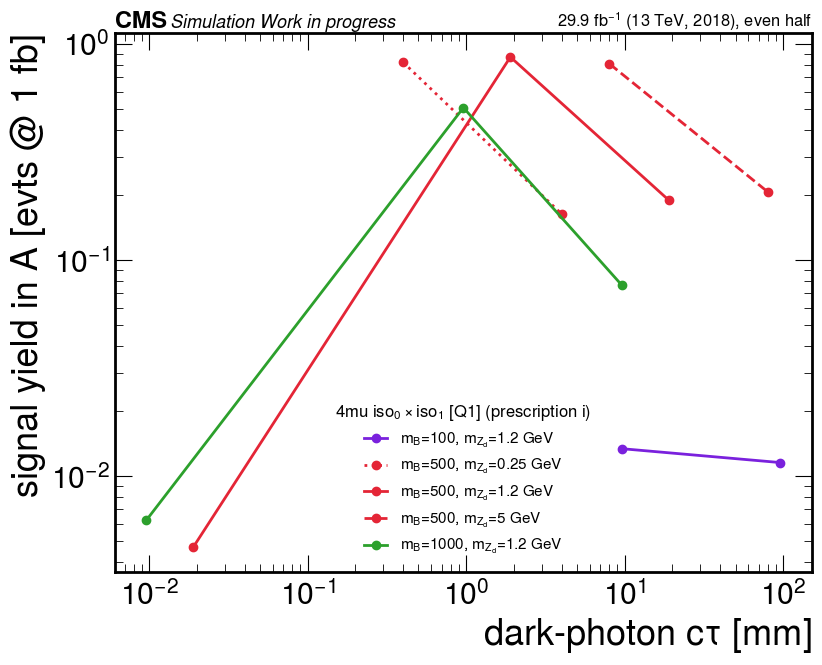

In [5]:
for ch, pname, presc in [("2mu2e", "P4_muiso_mjj", "i"), ("2mu2e", "P1_iso_iso", "iii"),
                         ("4mu", "Q1_iso_iso", "i")]:
    pts = {k.split("/", 3)[3]: v["S_A"] for k, v in results.items()
           if k.startswith(f"{ch}/{pname}/{presc}/") and v["S_A"] > 0}
    if pts:
        ph.eff_vs_ctau(pts, ylabel="signal yield in A [evts @ 1 fb]",
                       note=f"{ch} {ph.nice(pname)} (prescription {presc})")
    else:
        print(f"{ch}/{pname}/{presc}: no gate-3 anchor -> no calibrated efficiency "
              f"figure (see the Q6 expected-count table instead)")

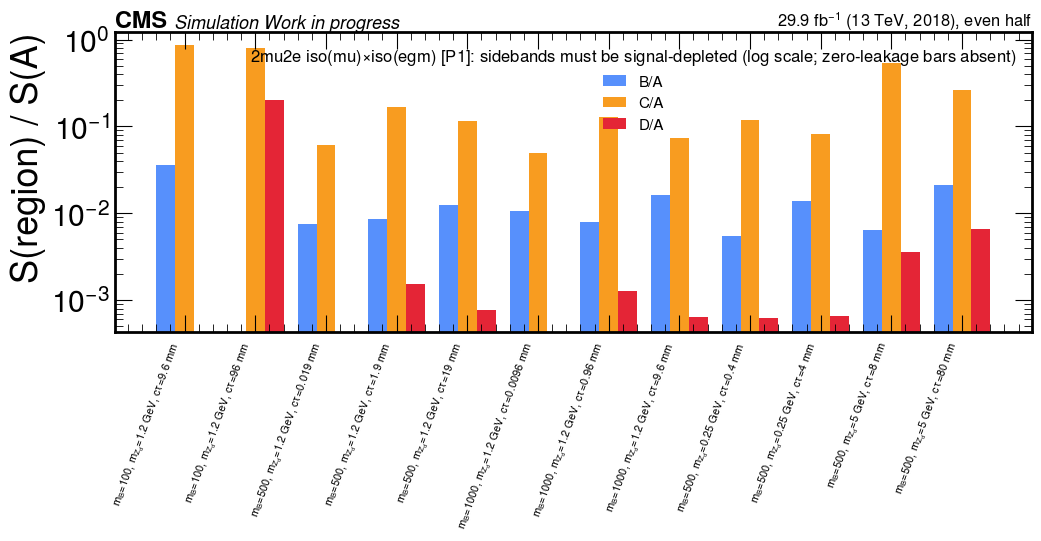

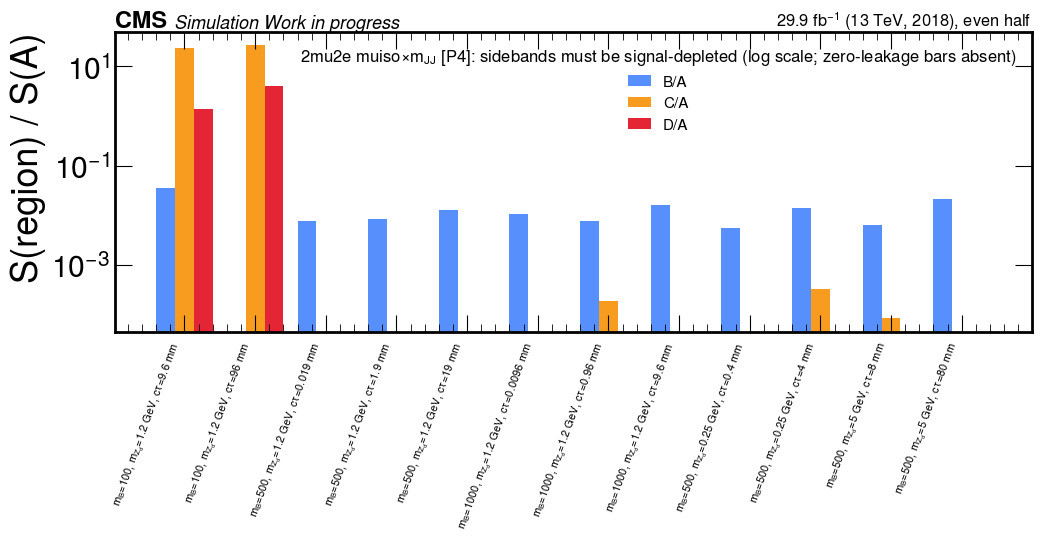

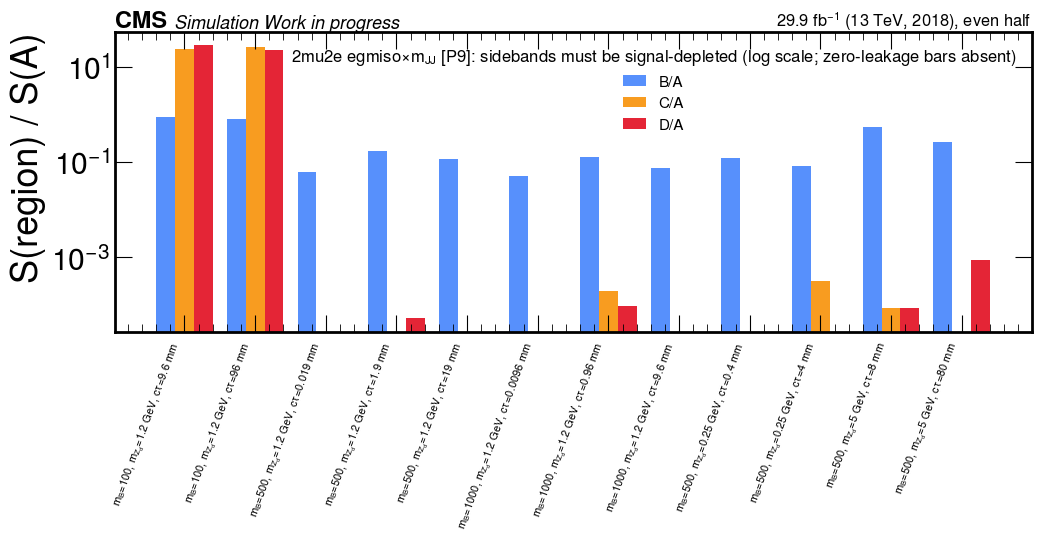

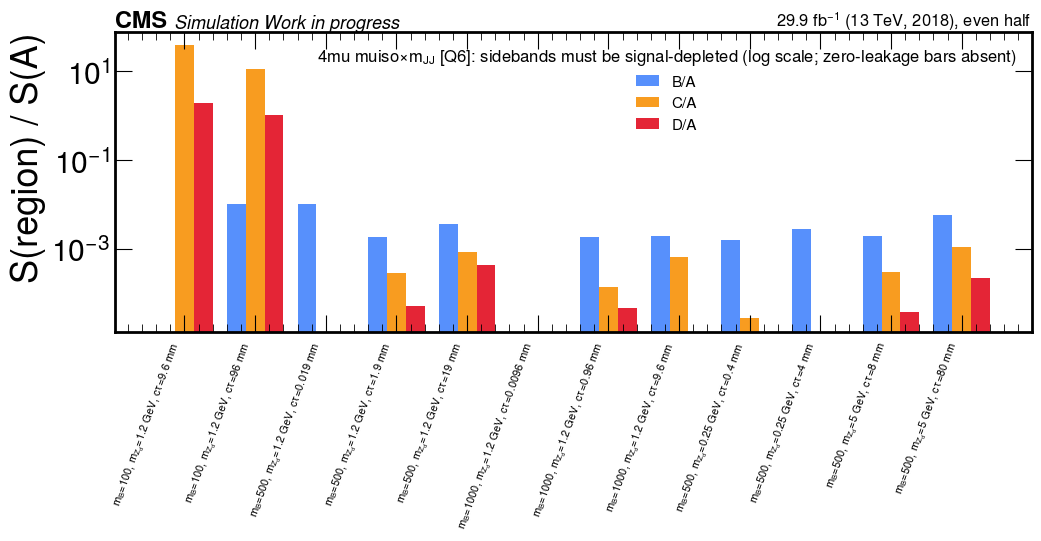

In [6]:
for ch, pname, sigs in [("2mu2e", "P1_iso_iso", ss.SIGNALS_2MU2E),
                        ("2mu2e", "P4_muiso_mjj", ss.SIGNALS_2MU2E),
                        ("2mu2e", "P9_egmiso_mjj", ss.SIGNALS_2MU2E),
                        ("4mu", "Q6_iso0_mjj", ss.SIGNALS_4MU)]:
    spec = ss.PLANES[ch][pname]
    series = {"B/A": [], "C/A": [], "D/A": []}
    names = []
    for s in sigs:
        sv, sw, sxe, sye = ss.plane_arrays(load_sig(s), ch, pname, parity=0)
        sreg = at.region_sums(sv, sw, sxe, sye, spec["xspec"], spec["yspec"])
        if sreg["A"][0] <= 0:
            continue
        lk = at.leakage_ratios(sreg)
        names.append(s)
        for kreg in ("B", "C", "D"):
            series[f"{kreg}/A"].append(lk.get(kreg, np.nan))
    if names:
        ph.bars_by_point(names, series, "S(region) / S(A)",
                         f"{ch} {ph.nice(pname)}: sidebands must be signal-depleted "
                         f"(log scale; zero-leakage bars absent)", log=True)

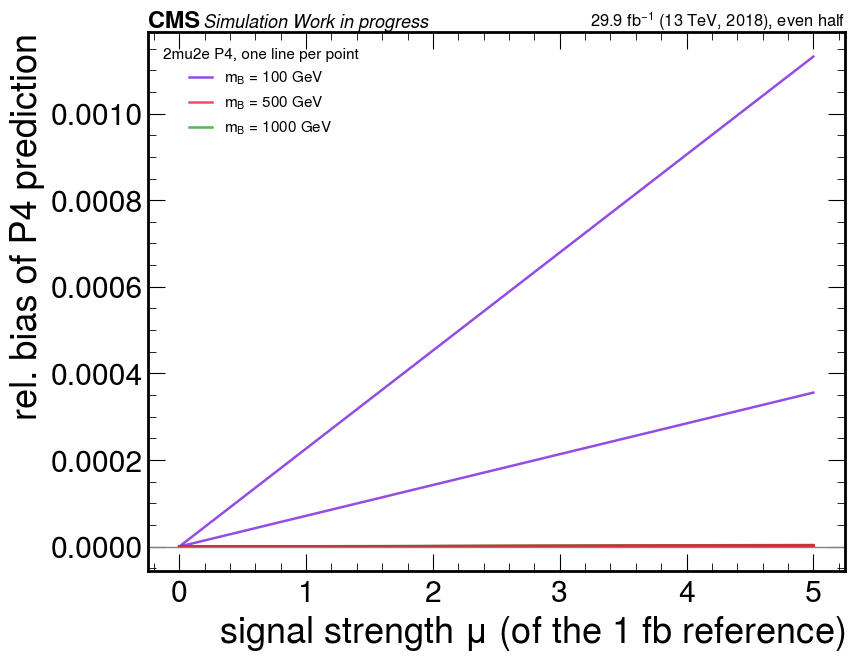

In [7]:
spec = ss.PLANES["2mu2e"]["P4_muiso_mjj"]
bvals, bvar, xe, ye = ss.plane_arrays(total_bkg, "2mu2e", "P4_muiso_mjj", parity=0)
breg = at.region_sums(bvals, bvar, xe, ye, spec["xspec"], spec["yspec"])
mus = list(np.linspace(0.0, 5.0, 11))
fig, axx = plt.subplots()
seen = set()
for s in ss.SIGNALS_2MU2E:
    sv, sw, sxe, sye = ss.plane_arrays(load_sig(s), "2mu2e", "P4_muiso_mjj", parity=0)
    sreg = at.region_sums(sv, sw, sxe, sye, spec["xspec"], spec["yspec"])
    ys = [b for _, b in at.prediction_bias_vs_mu(breg, sreg, mus)]
    if not np.any(np.isfinite(ys)):
        continue
    mB = ph.parse_sig(s)[0]
    axx.plot(mus, ys, lw=1.8, color=ph.MASS_COLORS[mB], alpha=0.8,
             label=f"$m_B$ = {mB:g} GeV" if mB not in seen else None)
    seen.add(mB)
axx.axhline(0, color="gray", lw=1)
axx.set_xlabel(r"signal strength $\mu$ (of the 1 fb reference)")
axx.set_ylabel("rel. bias of P4 prediction")
axx.legend(title="2mu2e P4, one line per point", fontsize=11, title_fontsize=11,
           framealpha=0.85)
cms_label(axx); plt.show()

## What the data continuation can actually measure: expected data counts

Weighted-MC totals over BOTH halves are the expected 2018 data counts (MC central
values) in each region at the SR working point. They set the closure precision the
data sidebands can reach — and expose that the low-mJJ validation region is sparse
at full SR cuts, so the data continuation also validates at loosened working points (the ladder),
where counts are ample.

In [8]:
for ch, pname in [("2mu2e", "P4_muiso_mjj"), ("4mu", "Q6_iso0_mjj")]:
    spec = ss.PLANES[ch][pname]
    vals, var, xe, ye = ss.plane_arrays(total_bkg, ch, pname)   # both halves
    reg = at.region_sums(vals, var, xe, ye, spec["xspec"], spec["yspec"])
    print(f"--- {ch} {pname}: expected 2018 data counts at the WP (MC central values)")
    for k in "ABCD":
        print(f"  {k}: {reg[k][0]:9.3g} +- {np.sqrt(max(reg[k][1], 0)):8.3g} (MC stat)")
    b, c, d = (reg[k][0] for k in "BCD")
    if min(b, c, d) > 0:
        rel = np.sqrt(1 / b + 1 / c + 1 / d)
        print(f"  -> B*C/D statistical precision with such counts: ~{rel:.0%}")

--- 2mu2e P4_muiso_mjj: expected 2018 data counts at the WP (MC central values)
  A:      57.2 +-     35.1 (MC stat)
  B:      85.4 +-     36.1 (MC stat)
  C:       117 +-      116 (MC stat)
  D:       178 +-      121 (MC stat)
  -> B*C/D statistical precision with such counts: ~16%


--- 4mu Q6_iso0_mjj: expected 2018 data counts at the WP (MC central values)
  A:   0.00263 +-  0.00263 (MC stat)
  B:     0.743 +-    0.662 (MC stat)
  C:   0.00526 +-  0.00372 (MC stat)
  D:     0.668 +-    0.661 (MC stat)
  -> B*C/D statistical precision with such counts: ~1389%


## Findings

- P4's mu-iso sideband holds ≤ 2.1% of the SR signal for every m_B ≥ 500 point
  (3.6% at the illustrative m_B = 100, cτ = 9.6 mm point), and its low-mJJ sideband
  leakage is below 10⁻³ (zero for most points, few ×10⁻⁴ at worst) — the leakage
  requirement is met where it matters. The m_B = 100 points dump 23–26× the SR
  yield into low mJJ (their resonance sits below the boundary); they are
  illustrative only, being produced at < 0.01 fb at the m_A = 750 GeV benchmark.
- The egm-iso-fail sidebands (P1's C region, P9's B region) hold up to ~86% of the
  SR signal for displaced points: displaced electron pairs reconstruct with large
  measured isolation. This disqualifies egm isolation as a plane axis independently
  of the factorization verdicts.
- Asimov Z values are indicative only (tight-WP B·C/D from the n_eff ≈ 1 regime);
  the honest sensitivity statement is efficiency + leakage + the notebook-02
  closure systematics, re-anchored on data sidebands in the data continuation.